In [1]:
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
import seaborn as sns

In [2]:
df = pd.read_csv("..\\datasets_paralelos\\spotify_padronizado.csv", encoding='utf-8', low_memory=True)

In [3]:
CLUSTER_FEATURES = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'valence',
    'tempo',
    'liveness',
    'instrumentalness',
]
X = df[CLUSTER_FEATURES]

# PCA

Definindo N componentes , mantendo a variância.

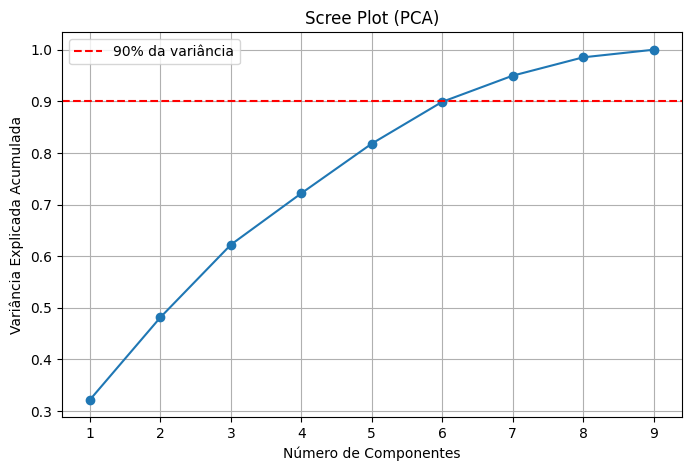

In [4]:
pca = PCA()
X_pca = pca.fit_transform(X)


explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% da variância')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Acumulada')
plt.title('Scree Plot (PCA)')
plt.grid(True)
plt.legend()
plt.show()

In [5]:
pca_final = PCA(n_components=6)
X_pca_final = pca_final.fit_transform(X)
df_pca = pd.DataFrame(X_pca_final, columns=[f'PC{i+1}' for i in range(X_pca_final.shape[1])])


# Kmeans

In [6]:
k = 7

In [7]:
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_pca_final)

df_pca['cluster'] = clusters
print(df_pca['cluster'].value_counts())

cluster
6    24110
0    18232
1    16020
4     9623
3     6552
2     5778
5     1028
Name: count, dtype: int64


In [8]:
nome_salvar = f'kmeans_{k}clusters_padronizado'

In [9]:
df_salvar = df.copy()
df_salvar['cluster'] = clusters
salvar = pd.concat([df[CLUSTER_FEATURES], df_salvar['cluster']], axis=1)
salvar.to_csv(f'..\\datasets_paralelos\\{nome_salvar}.csv', index=False)

In [10]:
eda = pd.read_csv('..\\datasets_paralelos\\spotify_limpo.csv', encoding='utf-8', low_memory=True)
eda['cluster'] = clusters
eda.to_csv(f'..\\datasets_paralelos\\spotify_eda_{k}clusters.csv', index=False)